<a href="https://colab.research.google.com/github/dieguito1331/cienciaDatos/blob/master/UCEMA/05 - Series de Tiempo (Prophet).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛒 Forecasting en Retail con Múltiples SKUs

En retail, una de las necesidades más frecuentes es anticipar la demanda futura de productos.
El desafío se vuelve complejo cuando cada SKU (producto) tiene patrones diferentes, tales como:

- Tendencias crecientes o decrecientes
- Estacionalidad semanal o anual
- Ruido o variabilidad alta
- Períodos sin ventas
- Cambios abruptos por promociones o eventos especiales

En entornos reales puede haber miles de SKUs, por lo que crear un modelo para cada uno de ellos
es una tarea que requiere un enfoque sistemático y reproducible.

En esta notebook vamos a:

1. Generar datos sintéticos representativos de un retailer real.
2. Explorar la evolución temporal de un SKU específico.
3. Entrenar dos modelos de forecasting:
   - **Prophet**
   - **ARIMA/SARIMAX**
4. Evaluar y comparar el rendimiento de ambos enfoques.
5. Discutir cómo escalar estos modelos a miles de SKUs en producción.

Este flujo representa un pipeline moderno de planificación comercial y reposición de inventarios.


# 🧪 Generación de Datos Sintéticos de Retail

Para poder ilustrar el caso, vamos a construir un dataset ficticio pero realista con las siguientes características:

- Ventas diarias durante 2 años.
- Tres SKUs con comportamientos distintos.
- Presencia de tendencia de largo plazo.
- Estacionalidad semanal clara (picos y valles por días específicos).
- Estacionalidad anual con variación suave.
- Ruido aleatorio para simular condiciones reales del negocio.

Este dataset nos permitirá practicar:

- Limpieza y manipulación de series temporales.
- Visualización por SKU.
- Entrenamiento de modelos clásicos de forecasting.
- Comparación de resultados entre distintos métodos.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Fechas
dates = pd.date_range("2021-01-01", "2022-12-31", freq="D")
n = len(dates)

# Lista de SKUs
skus = ["SKU_A", "SKU_B", "SKU_C"]

data = []

for sku in skus:
    # Tendencias distintas por SKU
    trend = np.linspace(
        50 if sku=="SKU_A" else 30 if sku=="SKU_B" else 70,
        100 if sku=="SKU_A" else 60 if sku=="SKU_B" else 120,
        n
    )

    # Estacionalidad semanal
    seasonal = 10 * np.sin(2 * np.pi * np.arange(n) / 7)

    # Estacionalidad anual
    seasonal_year = 20 * np.sin(2 * np.pi * np.arange(n) / 365)

    # Ruido
    noise = np.random.normal(0, 8, n)

    sales = trend + seasonal + seasonal_year + noise
    sales = np.maximum(sales, 0)  # no negativas

    for d, s in zip(dates, sales):
        data.append([sku, d, s])

df = pd.DataFrame(data, columns=["sku", "fecha", "ventas"])
df.head()

,sku,fecha,ventas
0,SKU_A,2021-01-01,53.973713
1,SKU_A,2021-01-02,57.125055
2,SKU_A,2021-01-03,65.756394
3,SKU_A,2021-01-04,67.761231
4,SKU_A,2021-01-05,45.438333


# 📊 Exploración de un SKU

Antes de entrenar un modelo, es fundamental entender visualmente el comportamiento de un SKU específico.
En esta sección vamos a:

- Seleccionar un SKU del dataset.
- Graficar su serie de tiempo con ventas diarias.
- Observar si existen patrones evidentes:
  - Tendencia creciente o decreciente.
  - Estacionalidad semanal.
  - Estacionalidad anual.
  - Ruido.
  - Comportamientos anómalos o discontinuidades.

Este análisis preliminar nos permite decidir qué modelos aplicar y qué transformaciones podrían ser necesarias.


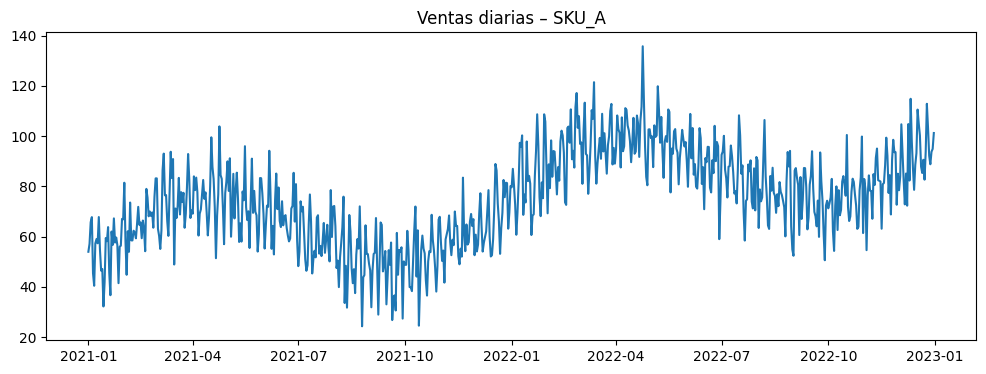

In [8]:
sku = "SKU_A"
df_sku = df[df["sku"] == sku].set_index("fecha")

plt.figure(figsize=(12,4))
plt.plot(df_sku["ventas"], label=sku)
plt.title(f"Ventas diarias – {sku}")
plt.show()

# 🔮 Forecasting con Prophet

**Prophet** es un modelo desarrollado por Meta (Facebook), diseñado específicamente para facilitar
el forecasting en contextos empresariales. Se destaca por su simpleza, interpretabilidad y buena
performance en escenarios con estacionalidad y ruido.

La estructura del modelo es aditiva:


y(t) = g(t) + s(t) + h(t) + ε(t)


donde:

- **g(t)** es la tendencia.
- **s(t)** es la estacionalidad (semanal, anual u otras).
- **h(t)** representa los efectos de feriados o eventos especiales.
- **ε** es el término de error.

### Ventajas de Prophet:

- Maneja múltiples estacionalidades de forma automática.
- Soporta tendencias no lineales.
- Incorpora feriados fácilmente.
- Produce gráficos interpretables (tendencia, estacionalidades).
- Requiere muy poca preparación del dataset (solo `ds` y `y`).

### Flujo de trabajo:

1. Preparar el dataset con columnas `ds` y `y`.
2. Dividirlo en entrenamiento y test según el tiempo.
3. Entrenar el modelo Prophet.
4. Generar el período futuro a predecir.
5. Evaluar el forecast contra el test.
6. Visualizar componentes interpretables del modelo.

Prophet es ideal como modelo base para retail, especialmente si
existen tendencias claras y estacionalidades fuertes.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is inco

/tmp/ipython-input-1150538498.py:13: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "bool"):


Versión de NumPy: 1.26.4


DEBUG:cmdstanpy:input tempfile: /tmp/tmp86f2yyhb/ix7840bg.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp86f2yyhb/ov48eu0w.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=35363', 'data', 'file=/tmp/tmp86f2yyhb/ix7840bg.json', 'init=/tmp/tmp86f2yyhb/ov48eu0w.json', 'output', 'file=/tmp/tmp86f2yyhb/prophet_modeloiqxu2kv/prophet_model-20251117225718.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:57:18 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:57:18 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray.

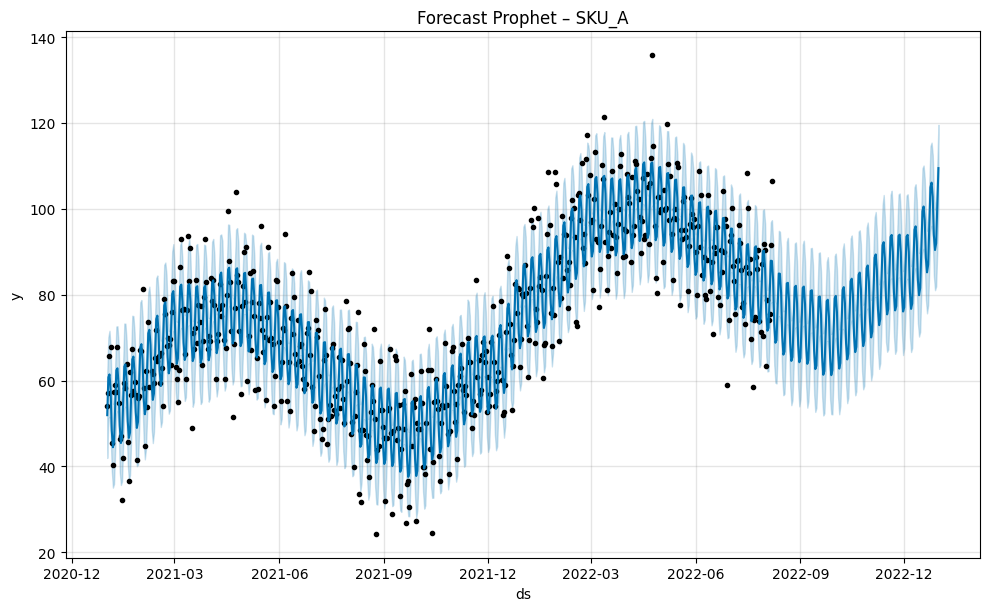

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:351: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df_y['ds'].dt.to_pydatetime(), seas[name], ls='-', c='#0072B2')
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:354: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` o

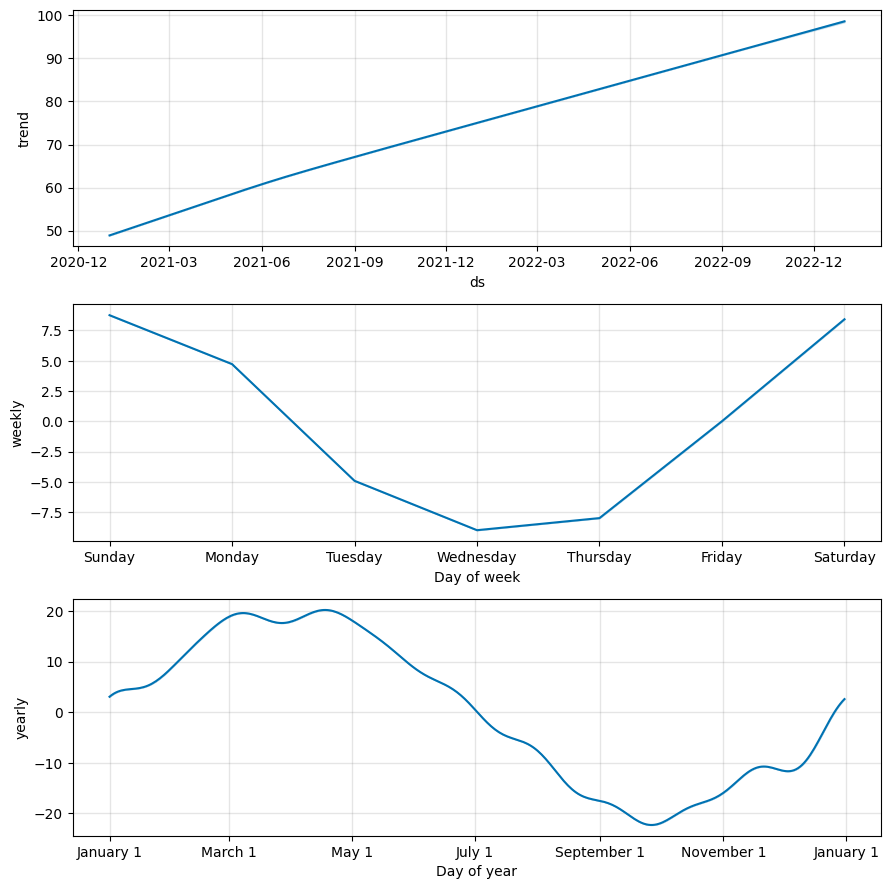

In [9]:
!pip install "numpy==1.26.4" "prophet==1.1.5" "cmdstanpy==1.2.0" --force-reinstall --quiet


import numpy as np

# Parche para compatibilidad con librerías viejas
if not hasattr(np, "float_"):
    np.float_ = np.float64
if not hasattr(np, "float"):
    np.float = np.float64
if not hasattr(np, "int"):
    np.int = np.int64
if not hasattr(np, "bool"):
    np.bool = np.bool_
#Revisar si se necesita en los codigos propios


print("Versión de NumPy:", np.__version__)

from prophet import Prophet


from prophet import Prophet

# Formato que Prophet espera
df_prophet = df_sku.reset_index()[["fecha","ventas"]]
df_prophet.columns = ["ds", "y"]

# Train / test split
split_date = df_prophet["ds"].quantile(0.8)
train = df_prophet[df_prophet["ds"] <= split_date]
test = df_prophet[df_prophet["ds"] > split_date]

m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

m.fit(train)

future = m.make_future_dataframe(periods=len(test))
forecast = m.predict(future)

# Gráfico
fig1 = m.plot(forecast)
plt.title(f"Forecast Prophet – {sku}")
plt.show()

# Componentes
m.plot_components(forecast)
plt.show()

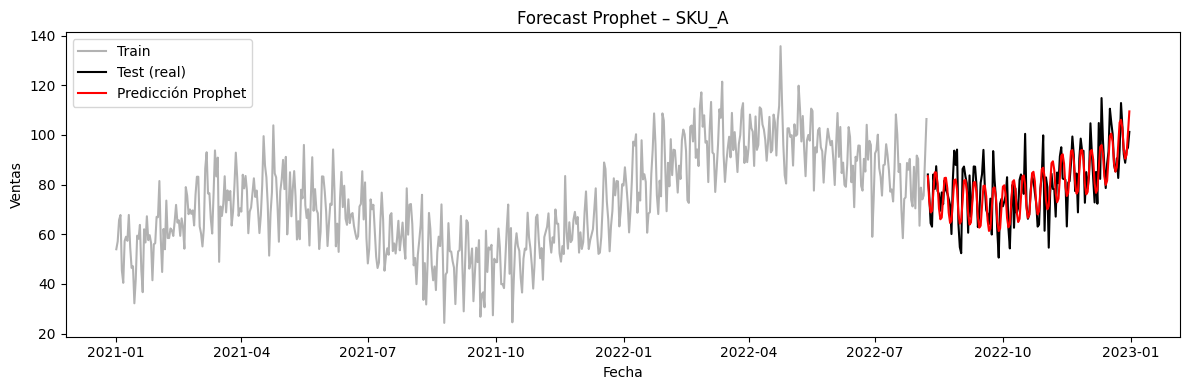

In [10]:
import matplotlib.pyplot as plt

# Alineamos las predicciones SOLO en el rango de test
forecast_idx = forecast.set_index("ds")
pred_test = forecast_idx.loc[test["ds"], "yhat"]

plt.figure(figsize=(12,4))

# (Opcional) histórico de train en gris
plt.plot(train["ds"], train["y"], label="Train", color="gray", alpha=0.6)

# Test real en negro
plt.plot(test["ds"], test["y"], label="Test (real)", color="black")

# Predicción Prophet en rojo
plt.plot(pred_test.index, pred_test.values, label="Predicción Prophet", color="red")

plt.title(f"Forecast Prophet – {sku}")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.tight_layout()
plt.show()

